# 07: Policy Network Development

This notebook builds and verifies the three neural networks at the heart of TFPnP:

1. **`ResNetActor_ADMM`** — the policy network $π_{\theta}$ that outputs $(\sigma_k, \mu_k)$ and the termination decision
2. **`ResNet_wobn`** — the value network (critic)
3. **`DRUNetDenoiser`** — the pretrained denoiser used in the ADMM x-step

Each network is developed inline first, then tested and explained, before importing from `ct_tfpnp/` and verifying the two agree.

## 1. Setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import weight_norm
import torchvision.models as tv_models
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import ct_tfpnp
from ct_tfpnp.datasets.lidc import from_HU_to_mu
from LION.CTtools.ct_utils import make_operator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"ct_tfpnp : {ct_tfpnp.__version__}")
print(f"torch    : {torch.__version__}")
print(f"device   : {device}")
if device.type == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name()}")

# set consistent plotting style for all notebook cells
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

# create output directory for figures
output_dir = Path("../figures/07")
output_dir.mkdir(parents=True, exist_ok=True)

# load test image
SLICE_PATH = ("/home/eaz21/rds/hpc-work/LIDC-IDRI/processed/LIDC-IDRI/"
              "LIDC-IDRI-0001/slice_104.npy")

gt_raw = np.load(SLICE_PATH).astype(np.float32)
gt = from_HU_to_mu(gt_raw)

print(f"\nTest image : {Path(SLICE_PATH).name}")
print(f"Shape      : {gt.shape}")
print(f"Range      : [{gt.min():.4f}, {gt.max():.4f}]  (LION-native µ, water ≈ 1.0)")

gt_np = gt
IMG_SIZE = gt.shape[0]


# Small helpers reused throughout the notebook
def count_params(module):
    return sum(p.numel() for p in module.parameters())

def psnr(gt, recon, data_range=None):
    if isinstance(gt, torch.Tensor): gt = gt.cpu().numpy()
    if isinstance(recon, torch.Tensor): recon = recon.cpu().numpy()
    gt = gt.squeeze(); recon = recon.squeeze()
    if data_range is None:
        data_range = gt.max()
    mse = np.mean((gt - recon) ** 2)
    return 10 * np.log10(data_range ** 2 / mse) if mse > 0 else float("inf")

ct_tfpnp : 0.1.dev5+gcb41b39e8.d20260612
torch    : 2.5.1+cu121
device   : cuda
GPU      : NVIDIA A100-SXM4-80GB

Test image : slice_104.npy
Shape      : (512, 512)
Range      : [0.0000, 4.0710]  (LION-native µ, water ≈ 1.0)


## 2. The ResNet-18 Backbone

The policy and value networks in Wei et al. use the same feature extractor architecture with separate weights. This reproduction departs from that, as set out below.

### Table 1 as specified

Table 1 gives output sizes but no strides:

| Layer   | Config                | Output (input 128×128) |
|---------|-----------------------|------------------------|
| conv1   | 3×3, 64, s=2          | 64×64                  |
| layer1  | [3×3, 64] × 2,  s=2   | 32×32                  |
| layer2  | [3×3, 128] × 2, s=2   | 16×16                  |
| layer3  | [3×3, 256] × 2, s=2   | 8×8                    |
| layer4  | [3×3, 512] × 2, s=2   | 4×4                    |
| avgpool | 4×4 average pooling   | 1×1 (512-d)            |

There is no maxpool. The ÷2 between conv1 and layer1 comes from `layer1` itself running at stride 2, which is not how a stock ResNet-18 is built. Note also that the paper's `avgpool` is a literal 4×4 pool, which is global only because a 128×128 input happens to reduce to 4×4.

### Ours

We use a stock torchvision ResNet-18 with only `conv1` replaced to accept 5 channels. The stem
therefore keeps the ImageNet 7×7 kernel and the maxpool, and `layer1` keeps stride 1.

| Layer   | Config                | Output (input 512×512) |
|---------|-----------------------|------------------------|
| conv1   | 7×7, 64, s=2          | 256×256                |
| maxpool | 3×3, s=2              | 128×128                |
| layer1  | [3×3, 64] × 2,  s=1   | 128×128                |
| layer2  | [3×3, 128] × 2, s=2   | 64×64                  |
| layer3  | [3×3, 256] × 2, s=2   | 32×32                  |
| layer4  | [3×3, 512] × 2, s=2   | 16×16                  |
| avgpool | adaptive avg pool     | 1×1 (512-d)            |

**What matches.** Total downsampling is ÷32 in both, as are the channel widths (64/128/256/512), the block counts, and the 512-dimensional output.

**What differs.** The stem kernel is 7×7 rather than 3×3, and the second ÷2 is achieved by the maxpool rather than by a strided `layer1`. We also feed full 512×512 slices rather than the paper's 128×128 images, so `layer4` emits 16×16 instead of 4×4 and `AdaptiveAvgPool2d(1)` absorbs the difference. The feature extractor therefore operates at a coarser spatial scale relative to anatomy than the paper's. 

In [ ]:
def make_backbone(in_channels: int = 5) -> nn.Module:
    """
    Standard torchvision ResNet-18 with three modifications per Wei et al. Table 1
    """
    backbone = tv_models.resnet18(weights=None)
    backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
    return backbone

backbone_orig = tv_models.resnet18(weights=None)
backbone      = make_backbone(in_channels=5)

## 4. The Policy Network: Two Sub-policies

After the shared 512-d feature vector, the policy splits into two heads

The two actions have fundamentally different gradient estimators:

- π₁ is discrete — REINFORCE on the log-probability of the sampled action
- π₂ is continuous and deterministic — DDPG-style backprop through the ADMM environment

Having two heads on a shared backbone lets the feature extractor learn representations useful for both decisions, while keeping the optimisation paths separate.            

In [ ]:
class InlinePolicy(nn.Module):
    """
    Inline version of ResNetActor_ADMM, identical to ct_tfpnp.models.policy
    but written here for inspection. The two are verified to agree below.
    """
    def __init__(self, in_channels=5, n_action_steps=5,
                 sigma_range=(1.0, 5.0), mu_range=(10.0, 100.0)):
        super().__init__()
        self.n_action_steps = n_action_steps
        self.sigma_min, self.sigma_max = sigma_range
        self.mu_min,    self.mu_max    = mu_range

        # shared backbone
        backbone = make_backbone(in_channels=in_channels)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])

        # two output heads on top of the 512-d feature vector
        self.termination_head = nn.Linear(512, 2)       
        self.param_head       = nn.Linear(512, n_action_steps * 2) 

    def forward(self, x, z, u, noise_level, iter_frac):
        B, _, H, W = x.shape

        # ensure noise level and iteration fraction are broadcastable to the image shape
        noise_map = noise_level.view(B, 1, 1, 1).expand(B, 1, H, W)
        iter_map  = iter_frac.view(B, 1, 1, 1).expand(B, 1, H, W)

        # concatenate inputs along the channel dimension
        inp   = torch.cat([x, z, u, noise_map, iter_map], dim=1)
        feats = self.feature_extractor(inp).view(B, -1)

        # define logits for termination head
        stop_logits = self.termination_head(feats)

        # define parameters for parameter head
        raw       = torch.sigmoid(self.param_head(feats))        
        sigma_n   = raw[:, : self.n_action_steps]               
        mu_n      = raw[:, self.n_action_steps :]               
        sigma_seq = self.sigma_min + sigma_n * (self.sigma_max - self.sigma_min)
        mu_seq    = self.mu_min    + mu_n    * (self.mu_max    - self.mu_min)

        return stop_logits, sigma_seq, mu_seq

## 5. Import package for later use

Now import the `ResNetActor_ADMM` from `ct_tfpnp` to be used for the remainder of this notebook.

In [ ]:
from ct_tfpnp.models.policy import ResNetActor_ADMM

## 6. The Value Network: `ResNet_wobn`

The value network estimates expected cumulative reward from state s and is trained against the critic loss.

In [ ]:
class InlineResBlock(nn.Module):
    """
    Residual block, no batch normalisation, plain ReLU.
    """
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=True)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=True)

    def forward(self, x):
        return x + self.conv2(self.relu(self.conv1(x)))


class InlineCritic(nn.Module):
    """
    Inline version of ResNet_wobn, identical to ct_tfpnp.models.critic.
    """
    def __init__(self, in_channels=5, base_channels=64, n_blocks=8):
        super().__init__()
        self.head = nn.Conv2d(in_channels, base_channels, 3, padding=1, bias=True)
        self.body = nn.Sequential(*[InlineResBlock(base_channels) for _ in range(n_blocks)])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.tail = nn.Linear(base_channels, 1)

    def forward(self, x, z, u, noise_level, iter_frac):
        B, _, H, W = x.shape
        noise_map = noise_level.view(B, 1, 1, 1).expand(B, 1, H, W)
        iter_map  = iter_frac.view(B, 1, 1, 1).expand(B, 1, H, W)
        inp = torch.cat([x, z, u, noise_map, iter_map], dim=1)
        out = self.head(inp)
        out = self.body(out)
        return self.tail(self.pool(out).view(B, -1))


critic_inline = InlineCritic(in_channels=5, base_channels=64, n_blocks=8).to(device)
critic_inline.eval()

print(f"Inline critic parameters : {count_params(critic_inline):,}")
print(f"Policy / critic ratio    : {count_params(policy) / count_params(critic_inline):.1f}x")
print()
print("Critic is ~19× smaller than the policy — the policy's role is harder")
print("(predicting an action) than the critic's (regressing a scalar value).")

Inline critic parameters : 593,857
Policy / critic ratio    : 18.8×

Critic is ~19× smaller than the policy — the policy's role is harder
(predicting an action) than the critic's (regressing a scalar value).


#### Import

In [ ]:
from ct_tfpnp.models.critic import ResNet_wobn

## 7. The Denoiser: DRUNet

The denoiser is a DRUNet - a residual U-Net with noise-level map conditioning. 

A single pretrained network handles the full range σ ∈ [0, 50] by conditioning on the normalised noise level at every pixel.

We use DRUNet rather than the TFPnP paper's own denoiser to demonstrate that TFPnP generalises to different denoisers (as recommended by supervisor). DRUNet is one of the most widely used denoisers in the PnP literature.

In [ ]:
# import architecture
from ct_tfpnp.models.denoiser import DRUNet   

class InlineDRUNetDenoiser(nn.Module):
    """
    Inline version of DRUNetDenoiser.
    """
    def __init__(self, pretrained_path=None):
        super().__init__()
        self.net = DRUNet(in_channels=2, out_channels=1)
        if pretrained_path is not None:
            state = torch.load(pretrained_path, map_location="cpu", weights_only=True)
            self.net.load_state_dict(state)
            print(f"Loaded DRUNet weights from {pretrained_path}")

    def forward(self, z, sigma):
        # Accept (1, H, W) or (B, 1, H, W)
        squeezed = False
        if z.dim() == 3:
            z = z.unsqueeze(0)
            squeezed = True
        B, _, H, W = z.shape

        # per-image max normalisation to [0, 1]
        scale = z.view(B, -1).max(dim=1).values.view(B, 1, 1, 1).clamp(min=1e-8)
        z_01  = z / scale

        # Build σ/50 noise map 
        if isinstance(sigma, (int, float)):
            sigma_norm = torch.full((B, 1, H, W), sigma / 50.0,
                                    device=z.device, dtype=z.dtype)
        else:
            sigma_t    = sigma.to(z.device, z.dtype)
            sigma_norm = (sigma_t / 50.0).view(B, 1, 1, 1).expand(B, 1, H, W)

        # Concatenate image and noise map, denoise, scale back to original range
        inp = torch.cat([z_01, sigma_norm], dim=1)
        out = self.net(inp) * scale

        if squeezed:
            out = out.squeeze(0)
        return out


DENOISER_PATH = "/home/eaz21/rds/hpc-work/eaz21/results/baselines/drunet_gray.pth"

denoiser_inline = InlineDRUNetDenoiser(pretrained_path=DENOISER_PATH).to(device)
denoiser_inline.eval()

# Smoke-test on the real µ-valued CT slice
x_t = torch.tensor(gt_np, device=device).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
    out = denoiser_inline(x_t, sigma=2.0)
print(f"\nInline denoiser smoke test (σ=2.0):")
print(f"  Input range  : [{x_t.min():.3f}, {x_t.max():.3f}]")
print(f"  Output range : [{out.min():.3f}, {out.max():.3f}]")
print(f"  PSNR vs GT   : {psnr(gt_np, out[0, 0]):.2f} dB  (clean input → near-perfect)")

Loaded DRUNet weights from /home/eaz21/rds/hpc-work/eaz21/results/baselines/drunet_gray.pth

Inline denoiser smoke test (σ=2.0):
  Input range  : [0.000, 4.071]
  Output range : [-0.016, 4.151]
  PSNR vs GT   : 43.84 dB  (clean input → near-perfect)


#### Import and Verify Denoiser

In [23]:
from ct_tfpnp.models.denoiser import DRUNetDenoiser

denoiser = DRUNetDenoiser(pretrained_path=DENOISER_PATH).to(device)
denoiser.eval()

# Copy DRUNet weights from inline to package version (same arch, same weights)
denoiser.net.load_state_dict(denoiser_inline.net.state_dict())

with torch.no_grad():
    out_inline = denoiser_inline(x_t, sigma=2.0)
    out_pkg    = denoiser       (x_t, sigma=2.0)

assert torch.allclose(out_inline, out_pkg, atol=1e-5)
print(f"✓ Wrapper output agrees between inline and package")
print(f"  shape: {tuple(out_pkg.shape)}, range: [{out_pkg.min():.4f}, {out_pkg.max():.4f}]")
print(f"  DRUNet params: {count_params(denoiser):,}")

Loaded DRUNet weights from /home/eaz21/rds/hpc-work/eaz21/results/baselines/drunet_gray.pth
✓ Wrapper output agrees between inline and package
  shape: (1, 1, 512, 512), range: [-0.0161, 4.1515]
  DRUNet params: 32,638,656


## 8. Denoiser σ-Gradient Check

The gradient chain for the model-based π₂ update is:

$$\theta_2 \leftarrow \theta_2 + l_\theta \nabla_{\theta_2} V_\phi(\text{ADMM}(s, \pi_2(s)))$$

In [ ]:
# set denoiser to train mode
denoiser.train()

# calcularte gradient w.r.t. σ
sigma_diff = torch.tensor(2.0, device=device, requires_grad=True)
x_in       = torch.tensor(gt_np, device=device).unsqueeze(0).unsqueeze(0)

x_out = denoiser(x_in, sigma=sigma_diff)
loss  = x_out.mean()
loss.backward()

print(f"Denoiser gradient check: ∂H_σ/∂σ")
print(f"  sigma.grad : {sigma_diff.grad.item():.6e}")

assert sigma_diff.grad is not None and abs(sigma_diff.grad.item()) > 0, \
    "Zero gradient w.r.t. σ — check noise map construction in wrapper"
print(f"  ✓ Gradient flows through denoiser w.r.t. σ")
print(f"    Model-based RL update for π₂ will receive a non-zero training signal.")

denoiser.eval()

Denoiser gradient check: ∂H_σ/∂σ
  sigma.grad : 4.413748e-05
  ✓ Gradient flows through denoiser w.r.t. σ
    Model-based RL update for π₂ will receive a non-zero training signal.


DRUNetDenoiser(
  (net): DRUNet(
    (m_head): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (m_down1): Sequential(
      (0): ResBlock(
        (res): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
      )
      (1): ResBlock(
        (res): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
      )
      (2): ResBlock(
        (res): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )

## 9. DRUNet Systematic Validation

The σ-gradient check above confirms DRUNet is differentiable, which is necessary for the model-based π₂ update but not sufficient evidence that the denoiser is doing useful work on CT data. 

### Methodology

For each of 5 test images and each σ ∈ {1, 2, 3, 5, 10, 25}:

1. Normalise the µ-valued CT slice to [0, 1]
2. Add synthetic Gaussian noise at std = σ/50 (KAIR convention)
3. Run DRUNet with the matched σ
4. Measure PSNR(noisy, GT) and PSNR(denoised, GT); report the gain

The σ range deliberately includes both the policy's operating regime (σ ∈ [1, 5]) and higher values that test how DRUNet behaves outside what TFPnP will ever ask of it.

This is a standalone denoising test with clean Gaussian noise added to clean CT images. 

Loaded 5 test images for DRUNet validation:
  LIDC-IDRI-0011: range [0.000, 4.071]
  LIDC-IDRI-0012: range [0.000, 3.575]
  LIDC-IDRI-0013: range [0.000, 2.258]
  LIDC-IDRI-0014: range [0.000, 2.136]
  LIDC-IDRI-0015: range [0.000, 4.071]


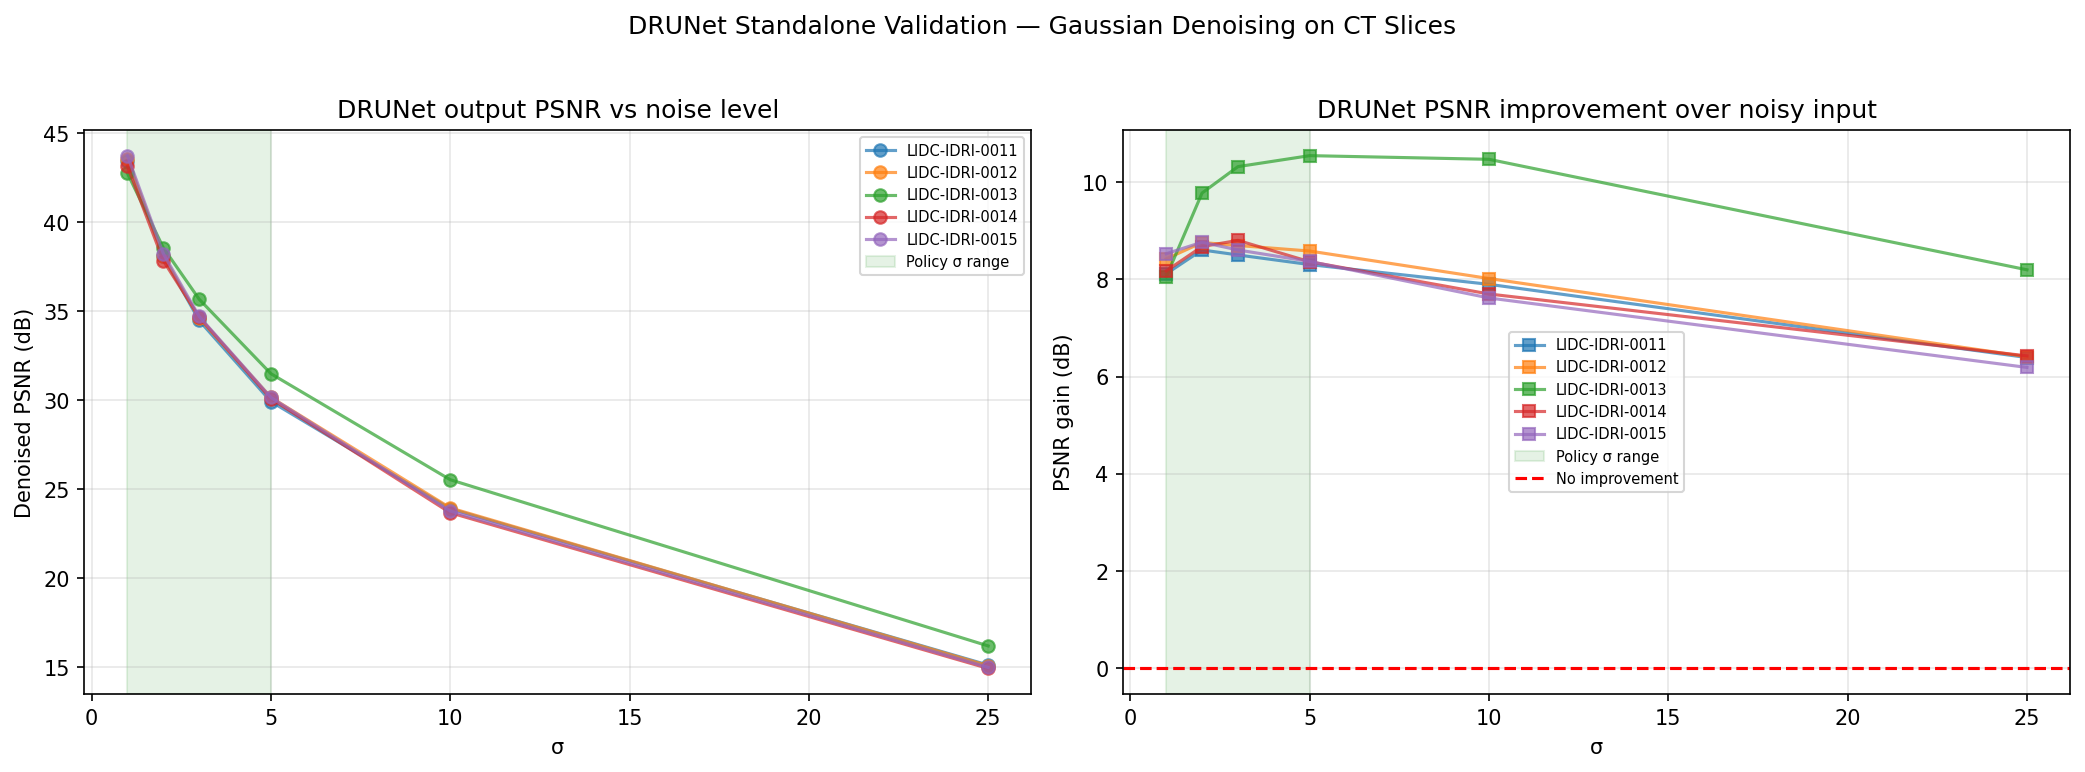


Mean PSNR gain across the 5 test images:
       noisy_psnr  denoised_psnr  gain_dB
sigma                                    
1       35.060001      43.320000     8.26
2       29.240000      38.160000     8.92
3       25.840000      34.820000     8.99
5       21.520000      30.360001     8.83
10      15.820000      24.160000     8.34
25       8.540000      15.260000     6.72


In [ ]:
import pandas as pd
from ct_tfpnp.datasets.lidc import from_HU_to_mu

# load 5 test images from different patients
data_dir = Path("/home/eaz21/rds/hpc-work/LIDC-IDRI/processed/LIDC-IDRI")
patients = sorted(p for p in data_dir.iterdir() if p.is_dir())[10:15]

test_imgs, test_labels = [], []
for pat_dir in patients:
    slices = sorted(pat_dir.glob("*.npy"))
    if slices:
        s = slices[len(slices) // 2]  # take a mid-stack slice
        img = from_HU_to_mu(np.load(s).astype(np.float32))
        test_imgs.append(torch.tensor(img, device=device).unsqueeze(0))  # (1, H, W)
        test_labels.append(pat_dir.name)

print(f"Loaded {len(test_imgs)} test images for DRUNet validation:")
for label, t in zip(test_labels, test_imgs):
    print(f"  {label}: range [{t.min():.3f}, {t.max():.3f}]")

# sweep over σ × images
sigma_levels = [1, 2, 3, 5, 10, 25]
drunet_results = []

denoiser.eval()
for img_idx, gt in enumerate(test_imgs):
    gt_01 = gt / gt.max() 

    for sigma_true in sigma_levels:
        noise_std = sigma_true / 50.0 
        torch.manual_seed(img_idx * 100 + sigma_true)
        noisy = (gt_01 + noise_std * torch.randn_like(gt_01)).clamp(min=0)

        noisy_psnr = psnr(gt_01, noisy)

        with torch.no_grad():
            denoised_01 = denoiser(noisy, sigma=float(sigma_true))

        denoised_psnr = psnr(gt_01, denoised_01)

        drunet_results.append({
            'image': test_labels[img_idx],
            'sigma': sigma_true,
            'noisy_psnr': noisy_psnr,
            'denoised_psnr': denoised_psnr,
            'gain_dB': denoised_psnr - noisy_psnr,
        })

df_drunet = pd.DataFrame(drunet_results)

# plot summary of results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for img_label in df_drunet['image'].unique():
    sub = df_drunet[df_drunet['image'] == img_label]
    axes[0].plot(sub['sigma'], sub['denoised_psnr'], 'o-', label=img_label, alpha=0.7)
    axes[1].plot(sub['sigma'], sub['gain_dB'], 's-', label=img_label, alpha=0.7)

for ax in axes:
    ax.axvspan(1, 5, alpha=0.1, color='green', label='Policy σ range')

axes[0].set_xlabel('σ'); axes[0].set_ylabel('Denoised PSNR (dB)')
axes[0].set_title('DRUNet output PSNR vs noise level')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('σ'); axes[1].set_ylabel('PSNR gain (dB)')
axes[1].set_title('DRUNet PSNR improvement over noisy input')
axes[1].axhline(0, color='red', ls='--', label='No improvement')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

plt.suptitle("DRUNet Standalone Validation — Gaussian Denoising on CT Slices", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / "01_drunet_validation.pdf", bbox_inches="tight")
plt.show()

# print summary statistics
print("\nMean PSNR gain across the 5 test images:")
print(df_drunet.groupby('sigma')[['noisy_psnr', 'denoised_psnr', 'gain_dB']].mean().round(2))

### Findings

A working DRUNet should show:

- Positive PSNR gain across all σ
- Larger gain at higher σ 
- Modest gain in the policy's operating regime (σ ∈ [1, 5], shaded green) 
- Per-image variation (different curves visible) 